# Fuzzy deduplication ablation for MMLU-PT

**Research question.** Which MinHash–LSH configuration removes incremental near-duplicate MCQA items after exact deduplication while minimizing the risk of discarding distinct questions?

## Abstract

This notebook is a reproducible ablation study of fuzzy deduplication for MMLU-PT. It compares question-only and full-MCQA text representations, four Locality Sensitive Hashing (LSH) operating points at a fixed 260-hash budget, character n-gram widths, and random seeds. The analysis combines corpus retention, subgroup shifts, exact character-shingle Jaccard audits, connected-component diagnostics, representative-policy comparisons, and run-time measurements. The notebook identifies duplicates but never removes records from the project dataset or reads annotation files.

## 1. Background and hypotheses

NeMo Curator's fuzzy workflow computes MinHash signatures over character n-grams, applies LSH, converts shared buckets into graph edges, finds weakly connected components, and emits IDs to remove. In version 1.3.0, removal is a separate workflow and `perform_removal` must remain `False`. See the [fuzzy deduplication guide](https://docs.nvidia.com/nemo/curator/latest/curate-text/process-data/deduplication/fuzzy), the [deduplication overview](https://docs.nvidia.com/nemo/curator/latest/curate-text/process-data/deduplication), and Chapter 3 of [Mining of Massive Datasets](https://infolab.stanford.edu/~ullman/mmds/book.pdf).

For `b` bands, `r` hashes per band, and Jaccard similarity `s`, the standard probability that a pair collides in at least one band is $P(\mathrm{candidate} \mid s)=1-(1-s^r)^b$. Therefore, with the total signature length held constant, more bands and fewer hashes per band make matching *less* strict. This conflicts with the strict/lenient direction stated in the current NeMo guide. This study consequently relies on the standard probability curve, the installed implementation's any-band matching behavior, and empirical exact-Jaccard audits—not on that prose direction.

Hypotheses:

1. Including choices reduces false positives caused by shared passages or boilerplate stems.
2. Looser LSH operating points increase coverage at the cost of lower pair precision and larger transitive components.
3. Character n-gram width changes sensitivity to short edits, especially for concise questions.
4. A defensible operating point should be stable across seeds and should not disproportionately remove a single exam or academic level.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
import math
import os
import platform
import shutil
import subprocess
import sys
import time
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from mmlu_pt.mcqa_minimal import PUBLIC_FIELDS, normalize_question_for_dedup

SEED = 42
RUN_EXPERIMENTS = False
RERUN_CONFIGS: set[str] = set()
INPUT_BLOCKSIZE = "256MiB"
MAX_EDGE_AUDIT = 100_000
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PATH"] = f"{Path(sys.executable).parent}:{os.environ['PATH']}"

sns.set_theme(context="paper", style="whitegrid", font_scale=1.05)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

def detect_gpu() -> tuple[bool, str]:
    executable = shutil.which("nvidia-smi")
    if executable is None:
        return False, "nvidia-smi is not installed"
    completed = subprocess.run(
        [executable, "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
        capture_output=True, text=True, check=False, timeout=15,
    )
    description = completed.stdout.strip() or completed.stderr.strip()
    return completed.returncode == 0 and bool(completed.stdout.strip()), description

REPO_ROOT = find_repo_root(Path.cwd())
INPUT_PATH = REPO_ROOT / "assets/sources/fuzzy_dedup/05 - deduplicated/0814daf3a224.jsonl"
ARTIFACT_BASE = REPO_ROOT / "output" / "fuzzy-deduplication-ablation" / "studies"
GPU_AVAILABLE, GPU_DESCRIPTION = detect_gpu()

print(f"Repository: {REPO_ROOT}")
print(f"Input: {INPUT_PATH}")
print(f"Python: {platform.python_version()}")
print(f"NeMo Curator: {importlib.metadata.version('nemo-curator')}")
print(f"GPU available: {GPU_AVAILABLE} ({GPU_DESCRIPTION})")

Repository: /home/aluno_paulosantana/repositories/mmlu-pt
Input: /home/aluno_paulosantana/repositories/mmlu-pt/assets/sources/fuzzy_dedup/05 - deduplicated/0814daf3a224.jsonl
Python: 3.12.3
NeMo Curator: 1.3.0
GPU available: True (NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04
NVIDIA B200, 183359 MiB, 580.178.04)


## 2. Dataset and reproducibility

The input is the output of exact deduplication, so every removal reported below is incremental. Files and records are deterministically ordered. `study_id` is a SHA-256 hash of all public fields and is used only for analysis; NeMo's generated integer ID is validated against row position before cluster metadata are joined back to the corpus.

In [2]:
input_files = [INPUT_PATH] if INPUT_PATH.is_file() else []
if not input_files:
    raise FileNotFoundError(
        f"Exact-deduplicated JSONL file not found: {INPUT_PATH}"
    )

frames = [pd.read_json(path, lines=True, convert_dates=False) for path in input_files]
data = pd.concat(frames, ignore_index=True)
missing_columns = sorted(set(PUBLIC_FIELDS) - set(data.columns))
if missing_columns:
    raise ValueError(f"Missing required public fields: {missing_columns}")
if data.empty or data["question"].isna().any():
    raise ValueError("The exact-deduplicated dataset is empty or contains null questions.")

def stable_record_id(row: pd.Series) -> str:
    payload = {field: row[field] for field in PUBLIC_FIELDS}
    encoded = json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()

data["study_id"] = data.apply(stable_record_id, axis=1)
if data["study_id"].duplicated().any():
    raise ValueError("Stable study IDs are not unique; inspect residual exact duplicates.")
data = data.sort_values("study_id").reset_index(drop=True)
data["expected_curator_id"] = np.arange(len(data), dtype=np.int64)

canonical_digest = hashlib.sha256()
for study_id in data["study_id"]:
    canonical_digest.update(study_id.encode("ascii"))
    canonical_digest.update(b"\n")
corpus_fingerprint = canonical_digest.hexdigest()

source_digest = hashlib.sha256()
for path in input_files:
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            source_digest.update(chunk)

STUDY_ROOT = ARTIFACT_BASE / corpus_fingerprint[:12]
INPUT_ARTIFACT_DIR = STUDY_ROOT / "input"
RUNS_DIR = STUDY_ROOT / "runs"
METRICS_PATH = STUDY_ROOT / "metrics.csv"

snapshot = pd.Series({
    "files": len(input_files),
    "records": len(data),
    "exams": data["exam"].nunique(),
    "exam_editions": data["exam_edition"].nunique(dropna=True),
    "academic_levels": data["academic_level"].nunique(),
    "corpus_fingerprint": corpus_fingerprint,
    "source_sha256": source_digest.hexdigest(),
    "study_root": str(STUDY_ROOT),
}, name="value")
display(snapshot.to_frame())

,value
files,1
records,39120
exams,17
exam_editions,1039
academic_levels,2
corpus_fingerprint,9603b934c72ceb641880da0aa02de34c1a4e55383f18a0593eb269c7f10fb456
source_sha256,79cb3c1f1330c875bdbddaa17635e728d6493fcc94c27c67a711508bde7bafc5
study_root,/home/aluno_paulosantana/repositories/mmlu-pt/output/fuzzy-deduplication-ablation/studies/9603b934c72c


In [3]:
def serialize_question_choices(question: str, choices: list[str]) -> str:
    labels = [chr(ord("A") + index) for index in range(len(choices))]
    choice_text = "\n".join(f"[{label}] {choice}" for label, choice in zip(labels, choices, strict=True))
    return normalize_question_for_dedup(f"{question}\n{choice_text}")

data["question_text"] = data["question"].map(normalize_question_for_dedup)
data["question_choices_text"] = [
    serialize_question_choices(question, choices)
    for question, choices in zip(data["question"], data["choices"], strict=True)
]
if (data[["question_text", "question_choices_text"]].map(len) == 0).any().any():
    raise ValueError("A fuzzy-deduplication representation is empty.")

representation_summary = pd.DataFrame({
    "representation": ["question", "question_choices"],
    "median_characters": [data["question_text"].str.len().median(), data["question_choices_text"].str.len().median()],
    "p95_characters": [data["question_text"].str.len().quantile(0.95), data["question_choices_text"].str.len().quantile(0.95)],
})
display(representation_summary)

,representation,median_characters,p95_characters
0,question,507.000,"1,923.000"
1,question_choices,878.000,"2,288.000"


## 3. Pre-registered compact sweep

The four main operating points keep `num_bands × minhashes_per_band = 260`, isolating the banding trade-off from signature length. The remaining runs test n-gram sensitivity and seed stability around NeMo's default. The primary representation is `question_choices`; question-only runs are a sensitivity analysis.

In [4]:
def collision_probability(similarity: np.ndarray | float, bands: int, rows: int):
    return 1 - (1 - np.asarray(similarity) ** rows) ** bands

def probability_midpoint(bands: int, rows: int) -> float:
    return float((1 - (1 - 0.5) ** (1 / bands)) ** (1 / rows))

main_bandings = [(10, 26), (13, 20), (20, 13), (26, 10)]
config_rows = []
for representation in ("question", "question_choices"):
    for bands, rows in main_bandings:
        config_rows.append({
            "slug": f"{representation}-b{bands}-r{rows}-n24-s42",
            "representation": representation, "num_bands": bands,
            "minhashes_per_band": rows, "char_ngrams": 24, "seed": 42, "family": "banding",
        })
for ngrams in (20, 30):
    config_rows.append({
        "slug": f"question_choices-b20-r13-n{ngrams}-s42",
        "representation": "question_choices", "num_bands": 20,
        "minhashes_per_band": 13, "char_ngrams": ngrams, "seed": 42, "family": "ngram",
    })
for seed in (17, 101):
    config_rows.append({
        "slug": f"question_choices-b20-r13-n24-s{seed}",
        "representation": "question_choices", "num_bands": 20,
        "minhashes_per_band": 13, "char_ngrams": 24, "seed": seed, "family": "seed",
    })

configs = pd.DataFrame(config_rows)
configs["num_hashes"] = configs["num_bands"] * configs["minhashes_per_band"]
configs["p50_similarity"] = [
    probability_midpoint(bands, rows)
    for bands, rows in zip(configs["num_bands"], configs["minhashes_per_band"], strict=True)
]
assert len(configs) == 12 and configs["slug"].is_unique
assert (configs["num_hashes"] == 260).all()
display(configs)

,slug,representation,num_bands,minhashes_per_band,char_ngrams,seed,family,num_hashes,p50_similarity
0,question-b10-r26-n24-s42,question,10,26,24,42,banding,260,0.901
1,question-b13-r20-n24-s42,question,13,20,24,42,banding,260,0.863
2,question-b20-r13-n24-s42,question,20,13,24,42,banding,260,0.771
3,question-b26-r10-n24-s42,question,26,10,24,42,banding,260,0.695
4,question_choices-b10-r26-n24-s42,question_choices,10,26,24,42,banding,260,0.901
5,question_choices-b13-r20-n24-s42,question_choices,13,20,24,42,banding,260,0.863
6,question_choices-b20-r13-n24-s42,question_choices,20,13,24,42,banding,260,0.771
7,question_choices-b26-r10-n24-s42,question_choices,26,10,24,42,banding,260,0.695
8,question_choices-b20-r13-n20-s42,question_choices,20,13,20,42,ngram,260,0.771
9,question_choices-b20-r13-n30-s42,question_choices,20,13,30,42,ngram,260,0.771


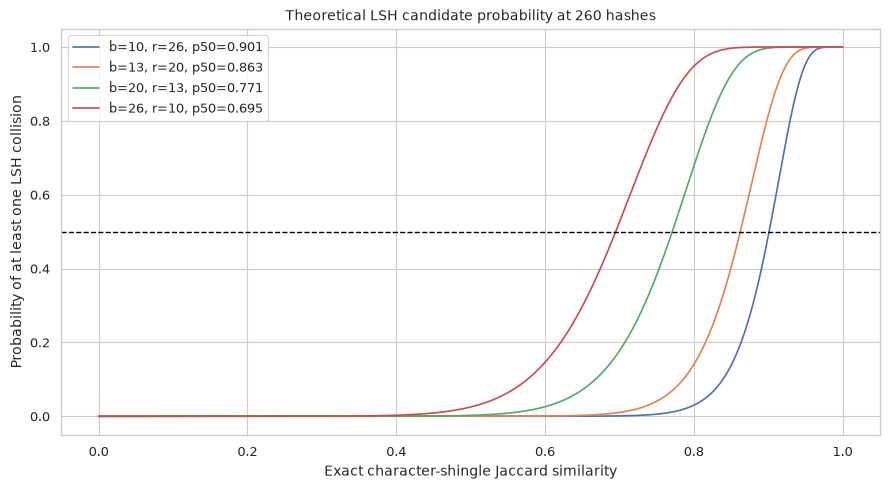

In [5]:
similarities = np.linspace(0, 1, 501)
plt.figure(figsize=(9, 5))
for bands, rows in main_bandings:
    plt.plot(similarities, collision_probability(similarities, bands, rows), label=f"b={bands}, r={rows}, p50={probability_midpoint(bands, rows):.3f}")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("Exact character-shingle Jaccard similarity")
plt.ylabel("Probability of at least one LSH collision")
plt.title("Theoretical LSH candidate probability at 260 hashes")
plt.legend()
plt.tight_layout()
plt.show()

## 4. GPU execution protocol

Set `RUN_EXPERIMENTS=True` and run all cells on a CUDA-capable host. Each configuration has isolated cache and result directories. To replace a completed run, add its exact slug to `RERUN_CONFIGS`; no broad output directory is deleted. The workflow only identifies candidates (`perform_removal=False`).

In [6]:
def directory_size(path: Path) -> int:
    return sum(item.stat().st_size for item in path.rglob("*") if item.is_file()) if path.exists() else 0

def representation_path(representation: str) -> Path:
    if representation not in {"question", "question_choices"}:
        raise ValueError(f"Unknown representation: {representation}")
    return INPUT_ARTIFACT_DIR / f"{representation}.parquet"

def materialize_representations() -> None:
    INPUT_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    for representation, column in {"question": "question_text", "question_choices": "question_choices_text"}.items():
        frame = pd.DataFrame({"fuzzy_text": data[column]})
        frame.to_parquet(representation_path(representation), index=False)

def validated_run_dir(slug: str) -> Path:
    if slug not in set(configs["slug"]):
        raise ValueError(f"Refusing an unknown configuration slug: {slug}")
    path = (RUNS_DIR / slug).resolve()
    if path.parent != RUNS_DIR.resolve():
        raise ValueError(f"Unsafe run directory: {path}")
    return path

def json_scalar(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    return value

def run_configuration(config: pd.Series) -> dict:
    from nemo_curator.stages.deduplication.fuzzy.workflow import FuzzyDeduplicationWorkflow

    slug = config["slug"]
    run_dir = validated_run_dir(slug)
    summary_path = run_dir / "summary.json"
    if summary_path.is_file() and slug not in RERUN_CONFIGS:
        return json.loads(summary_path.read_text(encoding="utf-8"))
    if run_dir.exists():
        if not any(run_dir.iterdir()):
            run_dir.rmdir()
        elif slug not in RERUN_CONFIGS:
            raise RuntimeError(f"Partial run exists for {slug}; inspect it or add the slug to RERUN_CONFIGS.")
        else:
            shutil.rmtree(run_dir)
    run_dir.mkdir(parents=True)
    cache_path = run_dir / "cache"
    result_path = run_dir / "results"
    started = time.time()
    workflow = FuzzyDeduplicationWorkflow(
        input_path=str(representation_path(config["representation"])),
        input_filetype="parquet", input_blocksize=INPUT_BLOCKSIZE,
        cache_path=str(cache_path), output_path=str(result_path),
        text_field="fuzzy_text", perform_removal=False,
        seed=int(config["seed"]), char_ngrams=int(config["char_ngrams"]),
        num_bands=int(config["num_bands"]),
        minhashes_per_band=int(config["minhashes_per_band"]),
        use_64_bit_hash=False, bands_per_iteration=min(5, int(config["num_bands"])),
    )
    result = workflow.run()
    id_generator_path = result_path / "fuzzy_id_generator.json"
    generator = json.loads(id_generator_path.read_text(encoding="utf-8"))
    ranges = list(generator.get("batch_registry", {}).values())
    if generator.get("next_id") != len(data) or ranges != [[0, len(data) - 1]]:
        raise ValueError(f"Generated IDs for {slug} do not match deterministic row positions: {generator}")
    summary = {
        **{key: json_scalar(value) for key, value in config.to_dict().items()},
        **{key: json_scalar(value) for key, value in result.metadata.items()},
        "wall_time": time.time() - started, "disk_bytes": directory_size(run_dir),
        "corpus_fingerprint": corpus_fingerprint,
        "source_sha256": snapshot["source_sha256"],
    }
    summary_path.write_text(json.dumps(summary, indent=2, sort_keys=True), encoding="utf-8")
    return summary

run_summaries = []
if RUN_EXPERIMENTS and not GPU_AVAILABLE:
    display(Markdown("**GPU sweep skipped:** `RUN_EXPERIMENTS=True`, but no usable NVIDIA GPU was detected."))
elif RUN_EXPERIMENTS:
    import ray
    from nemo_curator.core.client import RayClient

    materialize_representations()
    ray.shutdown()
    with RayClient(include_dashboard=False):
        for _, config in configs.iterrows():
            print(f"Running {config['slug']}")
            run_summaries.append(run_configuration(config))
else:
    display(Markdown("GPU execution is disabled. Existing complete runs will still be analyzed below."))

GPU execution is disabled. Existing complete runs will still be analyzed below.

## 5. Result integrity and corpus-level metrics

A run is considered complete only when its summary, ID-generator state, duplicate IDs, and connected-component artifacts are present. Partial caches are reported and never silently analyzed.

In [7]:
def read_parquet_tree(path: Path) -> pd.DataFrame:
    files = sorted(path.rglob("*.parquet")) if path.exists() else []
    return pd.concat((pd.read_parquet(file) for file in files), ignore_index=True) if files else pd.DataFrame()

def load_run(config: pd.Series) -> dict | None:
    run_dir = validated_run_dir(config["slug"])
    summary_path = run_dir / "summary.json"
    required = [summary_path, run_dir / "results" / "fuzzy_id_generator.json"]
    if not run_dir.exists():
        return None
    if not all(path.exists() for path in required):
        return {"status": "partial", "slug": config["slug"], "missing": [str(path) for path in required if not path.exists()]}
    summary = json.loads(summary_path.read_text(encoding="utf-8"))
    duplicate_count = int(summary.get("num_duplicates", 0))
    duplicate_path = run_dir / "results" / "FuzzyDuplicateIds"
    component_path = run_dir / "cache" / "ConnectedComponentsStage"
    if duplicate_count > 0 and (not duplicate_path.exists() or not component_path.exists()):
        missing = [str(path) for path in (duplicate_path, component_path) if not path.exists()]
        return {"status": "partial", "slug": config["slug"], "missing": missing}
    if summary.get("corpus_fingerprint") != corpus_fingerprint:
        return {"status": "stale", "slug": config["slug"]}
    duplicate_ids = read_parquet_tree(duplicate_path)
    components = read_parquet_tree(component_path)
    edges = read_parquet_tree(run_dir / "cache" / "BucketsToEdgesStage")
    id_column = "_curator_dedup_id"
    removal = set(duplicate_ids[id_column].astype(int)) if id_column in duplicate_ids else set()
    if any(identifier < 0 or identifier >= len(data) for identifier in removal):
        raise ValueError(f"Out-of-range duplicate IDs in {config['slug']}")
    if not components.empty:
        component_ids = components[id_column].astype(int)
        if component_ids.duplicated().any() or not component_ids.between(0, len(data) - 1).all():
            raise ValueError(f"Invalid connected-component IDs in {config['slug']}")
    return {"status": "complete", "summary": summary, "duplicate_ids": removal, "components": components, "edges": edges}

loaded_runs = {}
run_status = []
for _, config in configs.iterrows():
    loaded = load_run(config)
    status = "missing" if loaded is None else loaded["status"]
    run_status.append({"slug": config["slug"], "status": status})
    if loaded is not None and status == "complete":
        loaded_runs[config["slug"]] = loaded
display(pd.DataFrame(run_status))

,slug,status
0,question-b10-r26-n24-s42,complete
1,question-b13-r20-n24-s42,complete
2,question-b20-r13-n24-s42,complete
3,question-b26-r10-n24-s42,complete
4,question_choices-b10-r26-n24-s42,complete
5,question_choices-b13-r20-n24-s42,complete
6,question_choices-b20-r13-n24-s42,complete
7,question_choices-b26-r10-n24-s42,complete
8,question_choices-b20-r13-n20-s42,complete
9,question_choices-b20-r13-n30-s42,complete


In [8]:
baseline_exam_counts = data["exam"].value_counts()
baseline_exam_share = data["exam"].value_counts(normalize=True)

def cluster_enrichment(components: pd.DataFrame) -> pd.DataFrame:
    if components.empty:
        return pd.DataFrame()
    enriched = components.copy()
    ids = enriched["_curator_dedup_id"].astype(int).to_numpy()
    for column in ["study_id", "exam", "exam_edition", "academic_level", "answer", "choices"]:
        enriched[column] = data.iloc[ids][column].to_list()
    return enriched

metric_rows = []
subgroup_rows = []
for _, config in configs.iterrows():
    slug = config["slug"]
    if slug not in loaded_runs:
        continue
    loaded = loaded_runs[slug]
    removal = loaded["duplicate_ids"]
    components = cluster_enrichment(loaded["components"])
    group_field = "_duplicate_group_id"
    sizes = components.groupby(group_field).size() if not components.empty else pd.Series(dtype=int)
    cross_exam = components.groupby(group_field)["exam"].nunique().gt(1).sum() if not components.empty else 0
    retained = data.loc[~data["expected_curator_id"].isin(removal)]
    retained_share = retained["exam"].value_counts(normalize=True).reindex(baseline_exam_share.index, fill_value=0)
    exam_removal = (
        data.loc[data["expected_curator_id"].isin(removal), "exam"].value_counts().reindex(baseline_exam_counts.index, fill_value=0)
        / baseline_exam_counts
    )
    for dimension in ("exam", "academic_level"):
        baseline_counts = data[dimension].value_counts()
        retained_counts = retained[dimension].value_counts().reindex(baseline_counts.index, fill_value=0)
        for group_name, baseline_count in baseline_counts.items():
            subgroup_rows.append({
                "slug": slug, "dimension": dimension, "group": group_name,
                "baseline": int(baseline_count), "retained": int(retained_counts[group_name]),
                "removed": int(baseline_count - retained_counts[group_name]),
                "retention_pct": 100 * retained_counts[group_name] / baseline_count,
            })
    summary = loaded["summary"]
    metric_rows.append({
        **config.to_dict(), "duplicates": len(removal), "retention_pct": 100 * len(retained) / len(data),
        "clustered_documents": len(components), "components": len(sizes),
        "largest_component": int(sizes.max()) if len(sizes) else 0, "cross_exam_components": int(cross_exam),
        "max_exam_removal_pct": 100 * float(exam_removal.max()),
        "max_exam_share_shift_pp": 100 * float((retained_share - baseline_exam_share).abs().max()),
        "total_time_s": summary.get("total_time", summary.get("wall_time", np.nan)),
        "minhash_time_s": summary.get("minhash_time", np.nan), "lsh_time_s": summary.get("lsh_time", np.nan),
        "connected_components_time_s": summary.get("connected_components_pipeline_time", 0.0),
        "disk_gib": summary.get("disk_bytes", 0) / 1024**3,
    })
metrics = pd.DataFrame(metric_rows)
subgroup_metrics = pd.DataFrame(subgroup_rows)
if metrics.empty:
    display(Markdown("**No complete GPU runs are available.** The theoretical and data sections remain valid; enable the sweep on a CUDA host to populate the empirical sections."))
else:
    display(metrics.sort_values(["representation", "p50_similarity"], ascending=[True, False]))
    display(Markdown("### Retention by exam and academic level"), subgroup_metrics.sort_values(["dimension", "group", "slug"]))

,slug,representation,num_bands,minhashes_per_band,char_ngrams,seed,family,num_hashes,p50_similarity,duplicates,...,components,largest_component,cross_exam_components,max_exam_removal_pct,max_exam_share_shift_pp,total_time_s,minhash_time_s,lsh_time_s,connected_components_time_s,disk_gib
0,question-b10-r26-n24-s42,question,10,26,24,42,banding,260,0.901,1904,...,666,53,1,24.613,1.227,68.838,16.893,19.443,26.350,0.038
1,question-b13-r20-n24-s42,question,13,20,24,42,banding,260,0.863,2362,...,813,60,2,32.733,1.526,68.865,15.700,25.824,26.209,0.039
2,question-b20-r13-n24-s42,question,20,13,24,42,banding,260,0.771,3281,...,1004,80,5,63.780,2.748,74.479,15.317,33.101,24.940,0.039
3,question-b26-r10-n24-s42,question,26,10,24,42,banding,260,0.695,3655,...,1111,86,6,75.253,3.304,91.450,16.098,48.322,25.980,0.039
4,question_choices-b10-r26-n24-s42,question_choices,10,26,24,42,banding,260,0.901,985,...,487,26,0,12.252,0.626,61.118,16.578,17.562,25.836,0.038
5,question_choices-b13-r20-n24-s42,question_choices,13,20,24,42,banding,260,0.863,1354,...,596,44,0,16.004,0.865,69.734,17.164,25.518,25.848,0.038
6,question_choices-b20-r13-n24-s42,question_choices,20,13,24,42,banding,260,0.771,2036,...,817,53,0,26.490,1.320,75.496,16.722,31.906,25.773,0.039
8,question_choices-b20-r13-n20-s42,question_choices,20,13,20,42,ngram,260,0.771,2155,...,876,53,0,30.315,1.411,75.560,16.180,32.239,25.982,0.039
9,question_choices-b20-r13-n30-s42,question_choices,20,13,30,42,ngram,260,0.771,1980,...,780,51,0,25.647,1.290,86.578,16.086,36.922,32.371,0.039
10,question_choices-b20-r13-n24-s17,question_choices,20,13,24,17,seed,260,0.771,2021,...,821,53,0,26.378,1.313,75.457,16.197,33.069,25.068,0.039


### Retention by exam and academic level

,slug,dimension,group,baseline,retained,removed,retention_pct
18,question-b10-r26-n24-s42,academic_level,high_school,9243,8331,912,90.133
37,question-b13-r20-n24-s42,academic_level,high_school,9243,7994,1249,86.487
56,question-b20-r13-n24-s42,academic_level,high_school,9243,7309,1934,79.076
75,question-b26-r10-n24-s42,academic_level,high_school,9243,7049,2194,76.263
94,question_choices-b10-r26-n24-s42,academic_level,high_school,9243,8827,416,95.499
...,...,...,...,...,...,...,...
217,question_choices-b20-r13-n24-s101,exam,REVALIDA,1195,1195,0,100.000
198,question_choices-b20-r13-n24-s17,exam,REVALIDA,1195,1195,0,100.000
122,question_choices-b20-r13-n24-s42,exam,REVALIDA,1195,1195,0,100.000
179,question_choices-b20-r13-n30-s42,exam,REVALIDA,1195,1195,0,100.000


## 6. Exact-Jaccard and transitive-component audit

LSH supplies candidates rather than a hard similarity threshold, and the 1.3.0 workflow does not expose the older optional false-positive Jaccard stage. We therefore recompute exact set Jaccard over the character n-grams used by each run. At most `MAX_EDGE_AUDIT` unique graph edges are sampled deterministically per configuration. Component minima diagnose chaining: endpoints in one connected component need not directly resemble one another.

,slug,duplicates,largest_component,audited_edges,jaccard_p10,jaccard_median,edges_ge_0_8_pct,cross_exam_edges_pct
0,question-b10-r26-n24-s42,1904,53,3133,0.886,0.943,99.362,0.032
1,question-b13-r20-n24-s42,2362,60,4108,0.852,0.932,97.006,0.049
2,question-b20-r13-n24-s42,3281,80,6289,0.781,0.902,85.339,0.111
3,question-b26-r10-n24-s42,3655,86,7636,0.748,0.875,75.118,0.131
4,question_choices-b10-r26-n24-s42,985,26,1305,0.858,0.921,98.084,0.000
5,question_choices-b13-r20-n24-s42,1354,44,2006,0.822,0.905,93.769,0.000
6,question_choices-b20-r13-n24-s42,2036,53,3754,0.753,0.862,77.677,0.000
7,question_choices-b26-r10-n24-s42,2620,53,5081,0.679,0.832,62.330,0.000
8,question_choices-b20-r13-n20-s42,2155,53,3853,0.742,0.864,76.979,0.000
9,question_choices-b20-r13-n30-s42,1980,51,3542,0.749,0.860,76.708,0.000


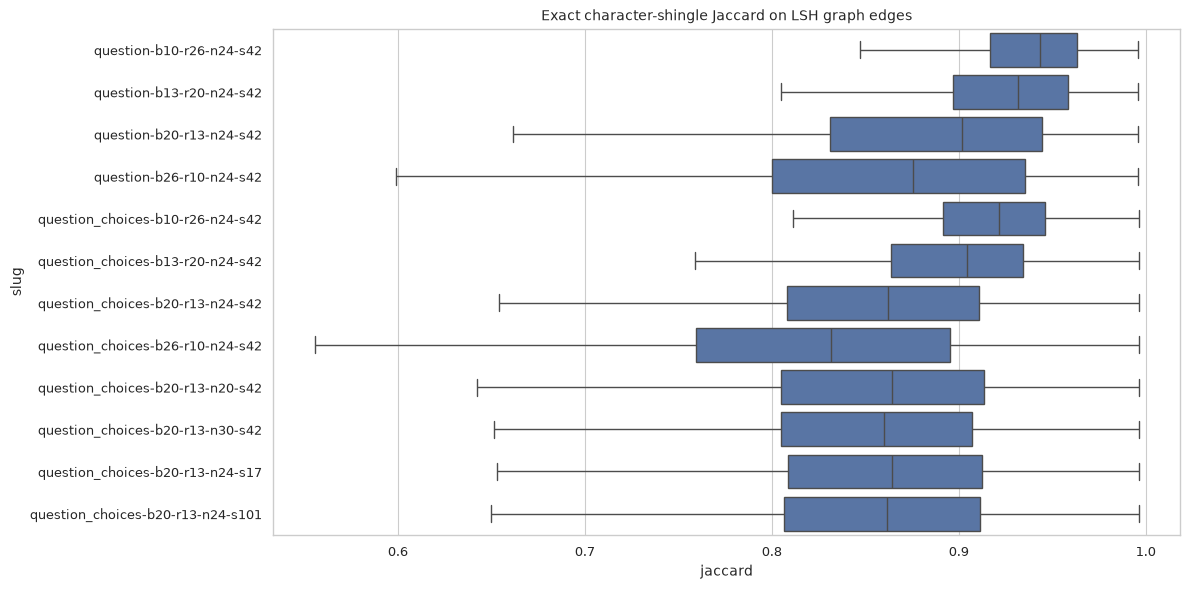

Consolidated automatic metrics: `/home/aluno_paulosantana/repositories/mmlu-pt/output/fuzzy-deduplication-ablation/studies/9603b934c72c/metrics.csv`

In [9]:
def shingles(text: str, width: int) -> set[str]:
    return {text[index:index + width] for index in range(max(0, len(text) - width + 1))}

def exact_jaccard(left: str, right: str, width: int) -> float:
    left_set, right_set = shingles(left, width), shingles(right, width)
    union = left_set | right_set
    return len(left_set & right_set) / len(union) if union else 1.0

def audited_edges(config: pd.Series, loaded: dict) -> pd.DataFrame:
    edges = loaded["edges"].copy()
    expected = {"_curator_dedup_id_x", "_curator_dedup_id_y"}
    if edges.empty or not expected.issubset(edges.columns):
        return pd.DataFrame(columns=["left_id", "right_id", "jaccard"])
    pairs = edges.rename(columns={"_curator_dedup_id_x": "left_id", "_curator_dedup_id_y": "right_id"})[["left_id", "right_id"]].astype(int)
    pairs[["left_id", "right_id"]] = np.sort(pairs[["left_id", "right_id"]].to_numpy(), axis=1)
    pairs = pairs[pairs["left_id"] != pairs["right_id"]].drop_duplicates().reset_index(drop=True)
    if len(pairs) > MAX_EDGE_AUDIT:
        pairs = pairs.sample(MAX_EDGE_AUDIT, random_state=SEED).sort_values(["left_id", "right_id"]).reset_index(drop=True)
    text_column = "question_text" if config["representation"] == "question" else "question_choices_text"
    width = int(config["char_ngrams"])
    pairs["jaccard"] = [exact_jaccard(data.at[left, text_column], data.at[right, text_column], width) for left, right in pairs.itertuples(index=False)]
    pairs["same_exam"] = [data.at[left, "exam"] == data.at[right, "exam"] for left, right in pairs[["left_id", "right_id"]].itertuples(index=False)]
    components = loaded["components"]
    if components.empty:
        pairs["component_size"] = 0
    else:
        group_sizes = components.groupby("_duplicate_group_id").size()
        id_to_group = components.set_index("_curator_dedup_id")["_duplicate_group_id"]
        pairs["component_size"] = pairs["left_id"].map(id_to_group).map(group_sizes).fillna(0).astype(int)
    pairs["similarity_band"] = pd.cut(pairs["jaccard"], [-np.inf, 0.7, 0.8, 0.9, np.inf], labels=["<0.70", "0.70-0.80", "0.80-0.90", ">=0.90"], right=False).astype(str)
    pairs["component_band"] = pd.cut(pairs["component_size"], [-np.inf, 2, 5, np.inf], labels=["size=2", "size=3-5", "size>=6"], right=True).astype(str)
    pairs["origin_band"] = np.where(pairs["same_exam"], "same_exam", "cross_exam")
    pairs["audit_stratum"] = pairs[["similarity_band", "component_band", "origin_band"]].agg("|".join, axis=1)
    return pairs

edge_audits = {}
jaccard_rows = []
for _, config in configs.iterrows():
    slug = config["slug"]
    if slug not in loaded_runs:
        continue
    audit = audited_edges(config, loaded_runs[slug])
    edge_audits[slug] = audit
    jaccard_rows.append({
        "slug": slug, "audited_edges": len(audit),
        "jaccard_p10": audit["jaccard"].quantile(0.10) if len(audit) else np.nan,
        "jaccard_median": audit["jaccard"].median() if len(audit) else np.nan,
        "edges_ge_0_8_pct": 100 * audit["jaccard"].ge(0.8).mean() if len(audit) else np.nan,
        "cross_exam_edges_pct": 100 * (~audit["same_exam"]).mean() if len(audit) else np.nan,
    })
jaccard_metrics = pd.DataFrame(jaccard_rows)
if not metrics.empty:
    metrics = metrics.merge(jaccard_metrics, on="slug", how="left")
    display(metrics[["slug", "duplicates", "largest_component", "audited_edges", "jaccard_p10", "jaccard_median", "edges_ge_0_8_pct", "cross_exam_edges_pct"]])
    plot_data = pd.concat([frame.assign(slug=slug) for slug, frame in edge_audits.items() if not frame.empty], ignore_index=True) if any(not frame.empty for frame in edge_audits.values()) else pd.DataFrame()
    if not plot_data.empty:
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=plot_data, x="jaccard", y="slug", showfliers=False)
        plt.title("Exact character-shingle Jaccard on LSH graph edges")
        plt.tight_layout()
        plt.show()

    STUDY_ROOT.mkdir(parents=True, exist_ok=True)
    metrics.sort_values("slug").to_csv(METRICS_PATH, index=False)
    display(Markdown(f"Consolidated automatic metrics: `{METRICS_PATH}`"))

In [10]:
def component_diagnostics(config: pd.Series, loaded: dict) -> pd.DataFrame:
    components = cluster_enrichment(loaded["components"])
    if components.empty:
        return pd.DataFrame()
    text_column = "question_text" if config["representation"] == "question" else "question_choices_text"
    width = int(config["char_ngrams"])
    rows = []
    for group_id, group in components.groupby("_duplicate_group_id"):
        ids = sorted(group["_curator_dedup_id"].astype(int))
        all_pairs = list(combinations(ids, 2))
        sampled_pairs = all_pairs if len(all_pairs) <= 2_000 else [all_pairs[index] for index in np.linspace(0, len(all_pairs) - 1, 2_000, dtype=int)]
        similarities = [exact_jaccard(data.at[left, text_column], data.at[right, text_column], width) for left, right in sampled_pairs]
        rows.append({
            "group_id": group_id, "size": len(ids), "pair_sample": len(sampled_pairs),
            "minimum_jaccard": min(similarities), "median_jaccard": float(np.median(similarities)),
            "exams": group["exam"].nunique(), "editions": group["exam_edition"].nunique(dropna=True),
            "choice_variants": group["choices"].map(lambda value: json.dumps(value, ensure_ascii=False)).nunique(),
            "answer_variants": group["answer"].nunique(),
        })
    return pd.DataFrame(rows).sort_values(["minimum_jaccard", "size"], ascending=[True, False])

reference_slug = "question_choices-b20-r13-n24-s42"
if reference_slug in loaded_runs:
    reference_config = configs.set_index("slug").loc[reference_slug]
    reference_component_diagnostics = component_diagnostics(reference_config, loaded_runs[reference_slug])
    display(Markdown("### Reference configuration: components most exposed to transitive chaining"), reference_component_diagnostics.head(30))

### Reference configuration: components most exposed to transitive chaining

,group_id,size,pair_sample,minimum_jaccard,median_jaccard,exams,editions,choice_variants,answer_variants
83,661,6,15,0.386,0.415,1,3,2,2
345,1594,6,15,0.408,0.635,1,1,2,2
467,2036,2,1,0.495,0.495,1,1,2,2
366,1651,2,1,0.498,0.498,1,1,2,2
598,2315,2,1,0.511,0.511,1,1,2,2
420,1899,4,6,0.519,0.583,1,1,4,3
79,625,4,6,0.531,0.598,1,2,2,2
546,2199,2,1,0.532,0.532,1,1,2,1
758,2686,33,528,0.533,0.731,1,33,1,1
178,1056,2,1,0.547,0.547,1,1,2,2


## 7. Representation, seed, and representative-policy analyses

Choice and answer disagreements are diagnostics, not automatic proof of an error: an item can be duplicated with reordered choices or with an inconsistent answer key. NeMo 1.3.0 keeps the first item encountered within a shuffled group. We compare that behavior with a deterministic policy that keeps the item with the longest normalized full-MCQA representation, breaking ties by `study_id`. No policy is applied to the dataset here.

In [11]:
if not metrics.empty:
    banding_comparison = metrics[metrics["family"] == "banding"].pivot_table(
        index=["num_bands", "minhashes_per_band", "p50_similarity"],
        columns="representation", values=["duplicates", "largest_component", "edges_ge_0_8_pct"],
    )
    display(Markdown("### Representation ablation"), banding_comparison)

def clustered_ids(slug: str) -> set[int]:
    components = loaded_runs[slug]["components"]
    return set(components["_curator_dedup_id"].astype(int)) if not components.empty else set()

seed_slugs = ["question_choices-b20-r13-n24-s42", "question_choices-b20-r13-n24-s17", "question_choices-b20-r13-n24-s101"]
seed_rows = []
for left_slug, right_slug in combinations([slug for slug in seed_slugs if slug in loaded_runs], 2):
    left, right = clustered_ids(left_slug), clustered_ids(right_slug)
    union = left | right
    seed_rows.append({"left": left_slug, "right": right_slug, "clustered_document_jaccard": len(left & right) / len(union) if union else 1.0})
seed_stability = pd.DataFrame(seed_rows)
if not seed_stability.empty:
    display(Markdown("### Seed stability"), seed_stability)

def representative_policy_analysis(slug: str) -> pd.DataFrame:
    loaded = loaded_runs[slug]
    components = loaded["components"]
    if components.empty:
        return pd.DataFrame()
    rows = []
    for group_id, group in components.groupby("_duplicate_group_id"):
        ids = sorted(group["_curator_dedup_id"].astype(int))
        default_candidates = sorted(set(ids) - loaded["duplicate_ids"])
        default_keep = default_candidates[0] if default_candidates else ids[0]
        deterministic_keep = max(ids, key=lambda identifier: (len(data.at[identifier, "question_choices_text"]), data.at[identifier, "study_id"]))
        rows.append({
            "group_id": group_id, "size": len(ids), "default_keep": default_keep,
            "deterministic_keep": deterministic_keep, "policy_disagrees": default_keep != deterministic_keep,
            "characters_gained": len(data.at[deterministic_keep, "question_choices_text"]) - len(data.at[default_keep, "question_choices_text"]),
        })
    return pd.DataFrame(rows)

if reference_slug in loaded_runs:
    representative_analysis = representative_policy_analysis(reference_slug)
    display(representative_analysis.describe(include="all"))

### Representation ablation

duplicates                   \
representation                                question question_choices   
num_bands minhashes_per_band p50_similarity                               
10        26                 0.901           1,904.000          985.000   
13        20                 0.863           2,362.000        1,354.000   
20        13                 0.771           3,281.000        2,036.000   
26        10                 0.695           3,655.000        2,620.000   

                                            edges_ge_0_8_pct                   \
representation                                      question question_choices   
num_bands minhashes_per_band p50_similarity                                     
10        26                 0.901                    99.362           98.084   
13        20                 0.863                    97.006           93.769   
20        13                 0.771                    85.339           77.677   
26        10                 0.695                    75.118           62.330   

                                            largest_component                   
representation                                       question question_choices  
num_bands minhashes_per_band p50_similarity                                     
10        26                 0.901                     53.000           26.000  
13        20                 0.863                     60.000           44.000  
20        13                 0.771                     80.000           53.000  
26        10                 0.695                     86.000           53.000

### Seed stability

,left,right,clustered_document_jaccard
0,question_choices-b20-r13-n24-s42,question_choices-b20-r13-n24-s17,0.805
1,question_choices-b20-r13-n24-s42,question_choices-b20-r13-n24-s101,0.793
2,question_choices-b20-r13-n24-s17,question_choices-b20-r13-n24-s101,0.781


,group_id,size,default_keep,deterministic_keep,policy_disagrees,characters_gained
count,817.000,817.000,817.000,817.000,817,817.000
unique,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,True,NaN
freq,NaN,NaN,NaN,NaN,539,NaN
mean,"1,723.084",3.492,"12,130.594","20,184.297",NaN,66.393
std,737.224,3.375,"8,715.776","11,141.598",NaN,135.453
min,31.000,2.000,24.000,24.000,NaN,0.000
25%,"1,117.000",2.000,"4,725.000","10,410.000",NaN,0.000
50%,"1,850.000",2.000,"10,450.000","20,298.000",NaN,2.000
75%,"2,346.000",4.000,"17,647.000","29,952.000",NaN,82.000


## 8. Exported artifacts

Each corpus fingerprint has an isolated study directory containing deterministic Parquet inputs, per-configuration caches, NeMo outputs, summaries, and consolidated automatic metrics. This notebook does not read or write annotation files.

## 9. Threats to validity

1. **Candidate generation is probabilistic.** LSH has no deterministic semantic cutoff; seed comparisons quantify only part of this variation.
2. **Jaccard is lexical.** High character-shingle overlap is a useful audit signal but cannot decide whether two assessment items are pedagogically equivalent.
3. **Connected components can chain.** Two distant endpoints can be grouped through intermediate matches despite low direct similarity; component minima expose this risk.
4. **Automatic edge metrics do not establish global recall.** They describe predicted pairs but cannot count near-duplicates missed by every configuration.
5. **Source imbalance.** Aggregate removal is dominated by large exams, so subgroup retention and distribution shifts must accompany the headline number.
6. **Version specificity.** The execution code targets NeMo Curator 1.3.0. Later releases may change APIs, memory behavior, or candidate verification.
7. **Representative quality is not guaranteed by NeMo removal IDs.** A deterministic completeness policy is analyzed, but actual pipeline integration would require a separate implementation and review.